In [1]:
import numpy as np
import shap
shap.initjs()
import sklearn
import pandas as pd

import matplotlib.pyplot as plt
import numpy as np
import xgboost
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

C:\Users\marcu\Documents\Auditing-and-Explaining-the-Income-Prediction-Models\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#pip install ucimlrepo

In [3]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
adult = fetch_ucirepo(id=2) 
  
# data (as pandas dataframes) 
X = adult.data.features.copy()
y = adult.data.targets.copy().iloc[:, 0]
  
# metadata 
print(adult.metadata) 
  
# variable information 
print(adult.variables) 


{'uci_id': 2, 'name': 'Adult', 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult', 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv', 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 48842, 'num_features': 14, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'], 'target_col': ['income'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1996, 'last_updated': 'Tue Sep 24 2024', 'dataset_doi': '10.24432/C5XW20', 'creators': ['Barry Becker', 'Ronny Kohavi'], 'intro_paper': None, 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was extracted using the fol

In [4]:
## Preprocessing steps ##

# Missing numbers
X = X.replace("?", pd.NA)

y = y.astype(str).str.strip()


valid_target = y.isin(["<=50K", ">50K", "<=50K.", ">50K."])
X = X.loc[valid_target]
y = y.loc[valid_target]

valid_X = X.notna().all(axis=1)
X = X.loc[valid_X]
y = y.loc[valid_X]


# Convert target to binary
y = y.map({
    "<=50K": 0,
    ">50K": 1,
    "<=50K.": 0,
    ">50K.": 1
})

print("X shape:", X.shape)
print("y shape:", y.shape)
print("NaNs in y:", y.isna().sum())
print("Class distribution:")
print(y.value_counts())

# Separate categorical and numerical features
categorical_cols = X.select_dtypes(include=["object", "string"]).columns
numeric_cols = X.select_dtypes(exclude=["object", "string"]).columns

# One-hot encode categorical features
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

X shape: (45222, 14)
y shape: (45222,)
NaNs in y: 0
Class distribution:
income
0    34014
1    11208
Name: count, dtype: int64


In [5]:
## Train/test split ##
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTrain/test shapes:")
print(X_train.shape, X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())


Train/test shapes:
(36177, 96) (9045, 96)
income
0    27211
1     8966
Name: count, dtype: int64
income
0    6803
1    2242
Name: count, dtype: int64


In [6]:
## Feature scaling (mainly for nn) ##
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
# Convert features to numeric for XGBoost
X_train_num = X_train.astype("float32")
X_test_num = X_test.astype("float32")

y_train_num = y_train.astype("int")
y_test_num = y_test.astype("int")

## XGBOOST

In [8]:
from xgboost import XGBClassifier

In [9]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train_num, y_train_num)

# Save model
xgb_model.save_model("xgb_model.json")

In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

y_pred = xgb_model.predict(X_test_num)
y_proba = xgb_model.predict_proba(X_test_num)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8688778330569376
ROC AUC: 0.9249544299013802

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.95      0.92      6803
           1       0.79      0.64      0.71      2242

    accuracy                           0.87      9045
   macro avg       0.84      0.79      0.81      9045
weighted avg       0.86      0.87      0.86      9045


Confusion Matrix:
 [[6435  368]
 [ 818 1424]]


In [11]:
print("Unique predicted probabilities:")
print(pd.Series(y_proba).round(6).value_counts().head(10))

print("Min prob:", y_proba.min())
print("Max prob:", y_proba.max())
print("Mean prob:", y_proba.mean())

Unique predicted probabilities:
0.000824    4
0.202345    4
0.000924    4
0.001101    4
0.000751    4
0.000855    4
0.000787    3
0.001413    3
0.000942    3
0.001210    3
Name: count, dtype: int64
Min prob: 0.0003597908
Max prob: 0.998459
Mean prob: 0.24338882


In [12]:
#SAVING RESULTS
xgb_results = {
    "accuracy": accuracy_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba)
}

print(xgb_results)

{'accuracy': 0.8688778330569376, 'roc_auc': 0.9249544299013802}


                              feature  importance
28  marital-status_Married-civ-spouse    0.334241
30       marital-status_Never-married    0.079611
3                        capital-gain    0.049275
2                       education-num    0.044654
21                education_Doctorate    0.043495
39           occupation_Other-service    0.024726
35         occupation_Exec-managerial    0.022902
23                  education_Masters    0.019796
4                        capital-loss    0.018993
41          occupation_Prof-specialty    0.018949
25              education_Prof-school    0.017935
46         relationship_Not-in-family    0.017207
20                education_Bachelors    0.014705
48             relationship_Own-child    0.014534
36         occupation_Farming-fishing    0.013568


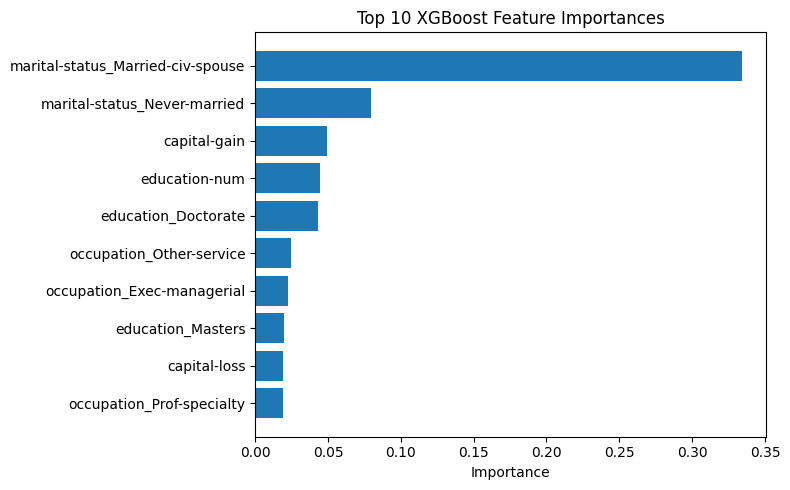

In [13]:
feature_importance = pd.DataFrame({
    "feature": X_train_num.columns,
    "importance": xgb_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print(feature_importance.head(15))

top_features = feature_importance.head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 10 XGBoost Feature Importances")
plt.tight_layout()
plt.show()

# SHAP on XGBOOST

In [14]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_num)

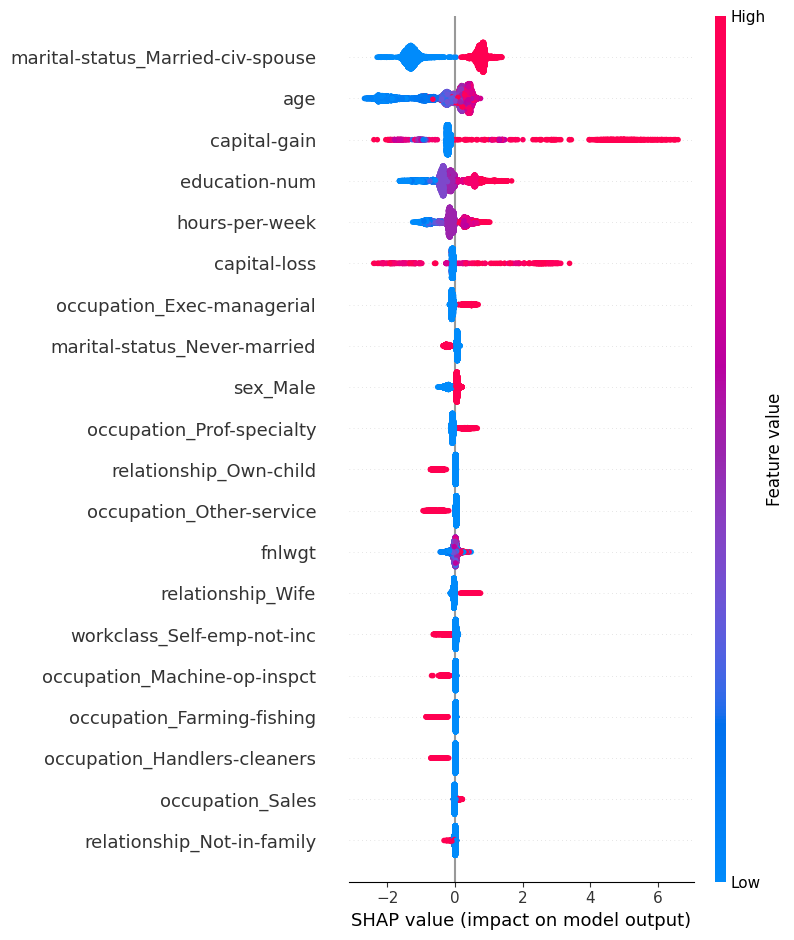

In [15]:
shap.summary_plot(shap_values, X_test_num)

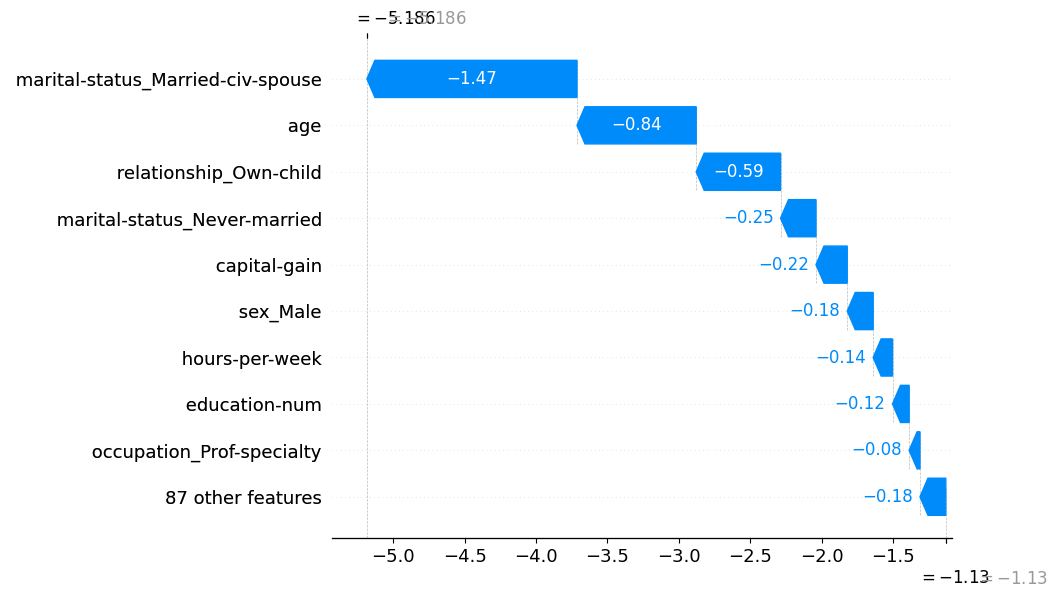

In [16]:
# For individuel person
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[0],
    X_test_num.iloc[0]
)

## LIME for individuel XGBOOST

LIME explanation as list:
[('capital-gain <= 0.00', -0.7180171429183574), ('marital-status_Married-civ-spouse <= 0.00', -0.12273665992800012), ('native-country_Jamaica <= 0.00', 0.09854123478146852), ('age <= 28.00', -0.09232550529342488), ('native-country_Columbia <= 0.00', -0.09018916135007239), ('hours-per-week <= 40.00', -0.078447787438349), ('workclass_Without-pay <= 0.00', -0.07527427894966739), ('native-country_Hungary <= 0.00', -0.061090502536583595), ('native-country_Ireland <= 0.00', 0.059051977302992775), ('native-country_Greece <= 0.00', 0.04367854082337279)]


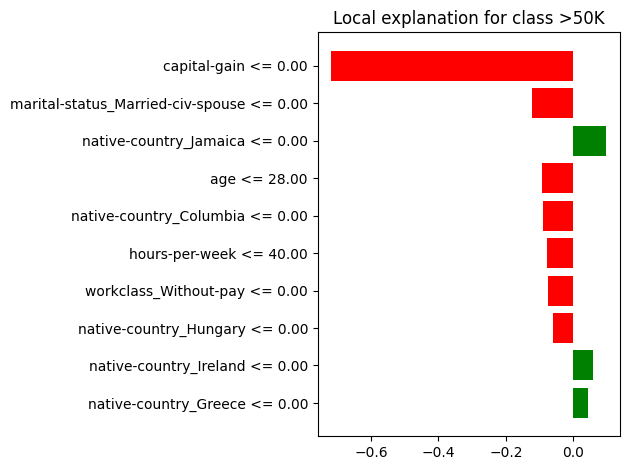

In [17]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train_num),
    feature_names=X_train_num.columns.tolist(),
    class_names=["<=50K", ">50K"],
    mode="classification"
)

exp = lime_explainer.explain_instance(
    data_row=X_test_num.iloc[0].values,
    predict_fn=xgb_model.predict_proba,
    num_features=10
)

print("LIME explanation as list:")
print(exp.as_list())

fig = exp.as_pyplot_figure()
plt.tight_layout()
plt.show()

# Neural Network

In [18]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Build neural network
nn_model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

# Compile
nn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Early stopping
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Train
history = nn_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

# Predict
y_proba_nn = nn_model.predict(X_test_scaled).ravel()
y_pred_nn = (y_proba_nn >= 0.5).astype(int)

# Save
nn_model.save("nn_model.keras")

# Evaluate
print("NN Accuracy:", accuracy_score(y_test, y_pred_nn))
print("NN ROC AUC:", roc_auc_score(y_test, y_proba_nn))
print("\nNN Classification Report:\n", classification_report(y_test, y_pred_nn))
print("\nNN Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nn))

Epoch 1/50
905/905 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8127 - loss: 0.4013 - val_accuracy: 0.8351 - val_loss: 0.3455
Epoch 2/50
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8414 - loss: 0.3446 - val_accuracy: 0.8389 - val_loss: 0.3381
Epoch 3/50
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8472 - loss: 0.3328 - val_accuracy: 0.8425 - val_loss: 0.3305
Epoch 4/50
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8500 - loss: 0.3253 - val_accuracy: 0.8419 - val_loss: 0.3298
Epoch 5/50
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8517 - loss: 0.3218 - val_accuracy: 0.8393 - val_loss: 0.3293
Epoch 6/50
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8529 - loss: 0.3185 - val_accuracy: 0.8434 - val_loss: 0.3276
Epoch 7/50
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8534 - loss: 0.3163 - val_accuracy: 0.8456 - val_loss: 0.3284
Epoch 8/50
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8572 - loss: 0.3130 - val_accuracy: 0.

# SHAP on NN

100%|██████████| 50/50 [00:22<00:00,  2.18it/s]


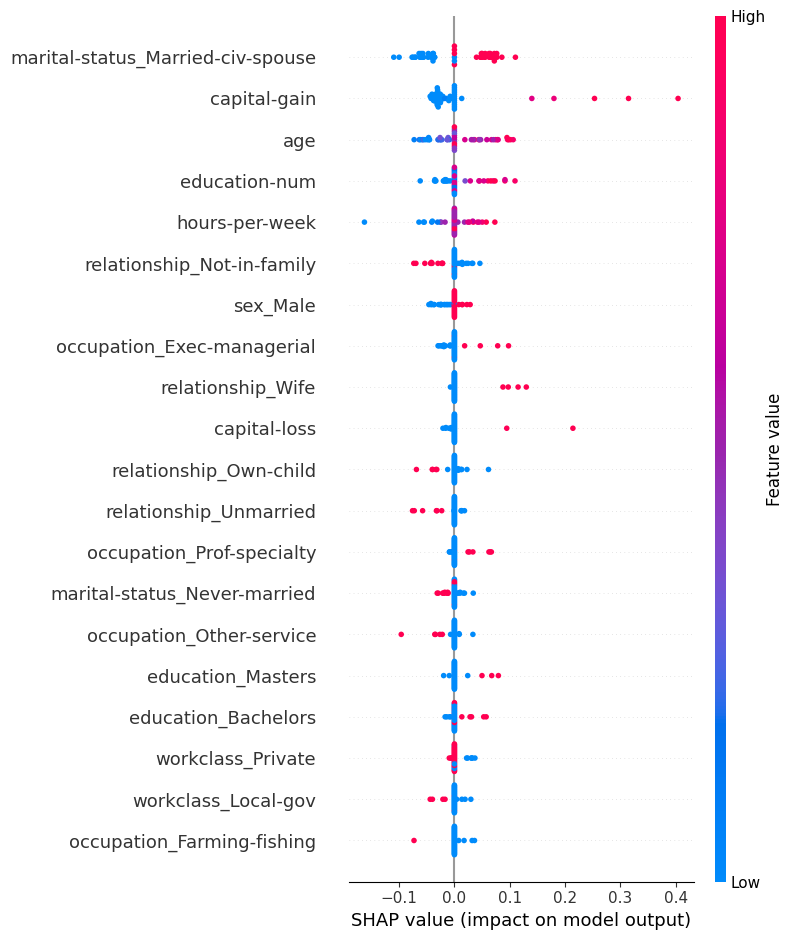

In [19]:
background = X_train_scaled[np.random.choice(X_train_scaled.shape[0], 100, replace=False)] # Background sample for SHAP
X_test_sample = X_test_scaled[:50] # Test sample to explain

# Wrapper so SHAP gets a 1D output
def nn_predict(x):
    return nn_model.predict(x, verbose=0).ravel()

explainer = shap.KernelExplainer(nn_predict, background)

shap_values = explainer.shap_values(X_test_sample, nsamples=100)

shap.summary_plot(
    shap_values,
    X_test_sample,
    feature_names=X_train.columns
)

In [20]:
instance = X_test_sample[0]

shap.force_plot(
    explainer.expected_value,
    shap_values[10],
    instance,
    feature_names=X_train.columns
)

## LIME on NN

[('capital-gain <= -0.15', -0.6448079262318538), ('native-country_France <= -0.03', -0.2412352223609338), ('occupation_Priv-house-serv <= -0.07', 0.19414242177697374), ('native-country_Columbia <= -0.04', 0.18321634733309666), ('capital-loss <= -0.22', -0.18003607571039118), ('native-country_Peru <= -0.03', 0.14990212124718658), ('native-country_Hong <= -0.02', 0.14206733876199357), ('native-country_Scotland <= -0.02', 0.12838152450966667), ('native-country_Honduras <= -0.02', 0.1263075785792228), ('native-country_Yugoslavia <= -0.02', -0.06166382662650854)]


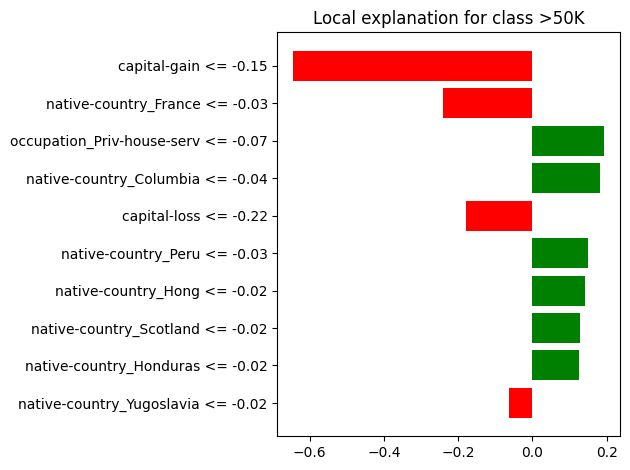

In [21]:
from lime.lime_tabular import LimeTabularExplainer

# NN predict_proba wrapper for LIME
def nn_predict_proba(x):
    p1 = nn_model.predict(x, verbose=0).ravel()
    p0 = 1 - p1
    return np.column_stack((p0, p1))

# LIME explainer
lime_explainer_nn = LimeTabularExplainer(
    training_data=np.array(X_train_scaled),
    feature_names=X_train.columns.tolist(),
    class_names=["<=50K", ">50K"],
    mode="classification"
)

# Explain one individual
idx = 0
exp_nn = lime_explainer_nn.explain_instance(
    data_row=X_test_scaled[idx],
    predict_fn=nn_predict_proba,
    num_features=10
)

print(exp_nn.as_list())

fig = exp_nn.as_pyplot_figure()
plt.tight_layout()
plt.show()